In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# SHAP
import shap

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
file_path = "/content/drive/MyDrive/UCI_Credit_Card.csv"
df = pd.read_csv(file_path)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Predictive Performance of the XGBoost Model

In [7]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

XGBoost Performance Metrics

In [8]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7675
Precision: 0.47992916174734357
Recall: 0.6126601356443104
F1-score: 0.5382323733862959
ROC-AUC: 0.7771647833092059


Confusion Matrix

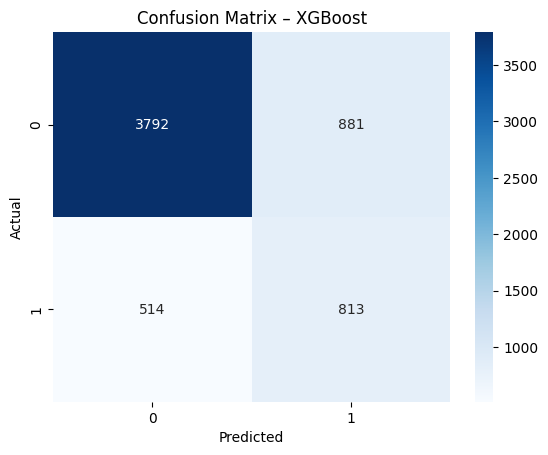

In [9]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – XGBoost")
plt.show()

ROC Curve

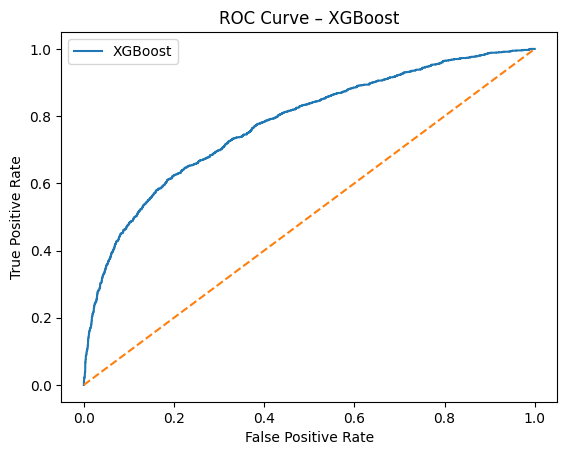

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend()
plt.show()

Comparison with Baseline Models



In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds),
        roc_auc_score(y_test, probs)
    ])

results.append([
    "XGBoost",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_prob)
])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.807333,0.716456,0.213263,0.328688,0.701639
1,Decision Tree,0.725833,0.387553,0.412962,0.399854,0.613821
2,XGBoost,0.767500,0.479929,0.612660,0.538232,0.777165


Global Model Explainability (SHAP)

In [12]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

SHAP Summary Plot (Global Importance)

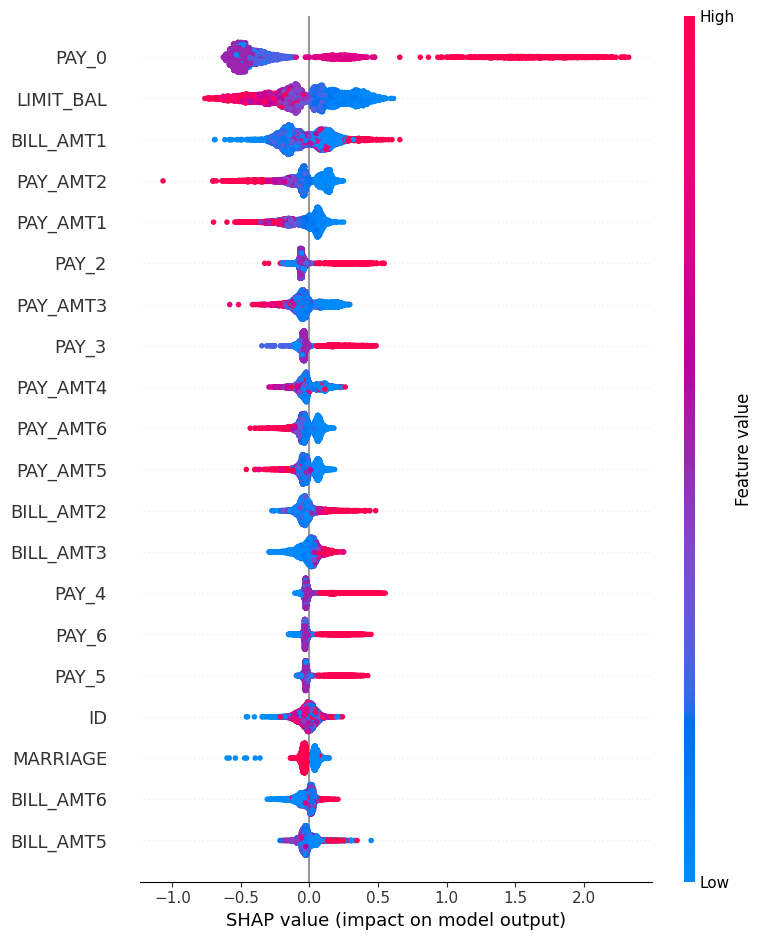

In [13]:
shap.summary_plot(shap_values, X_test)

Explain One Default Prediction

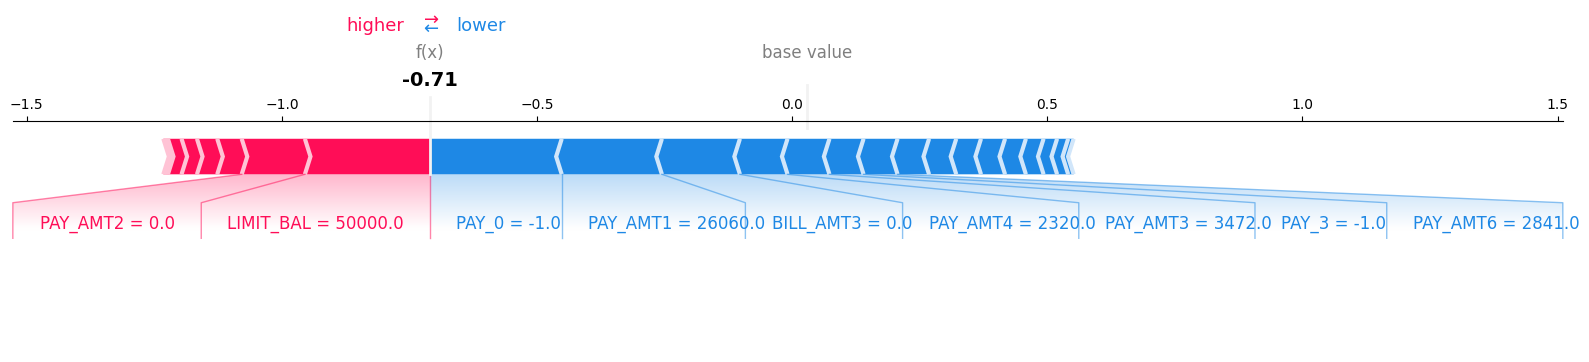

In [14]:
sample_index = X_test.index[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[X_test.index.get_loc(sample_index)],
    X_test.loc[sample_index],
    matplotlib=True
)

SHAP Visualizations



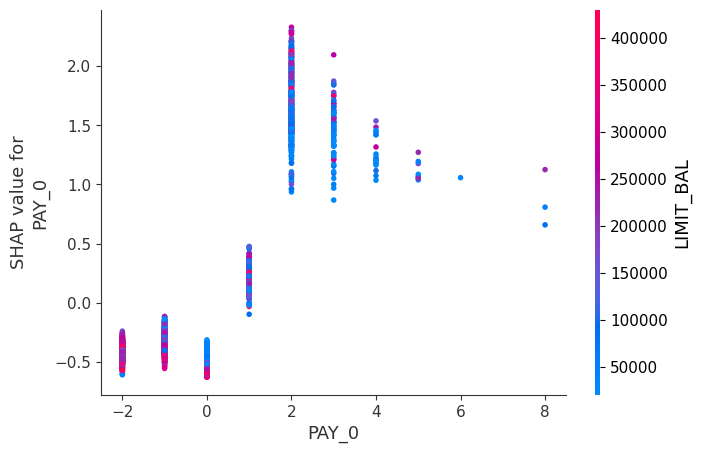

In [15]:
shap.dependence_plot("PAY_0", shap_values, X_test)

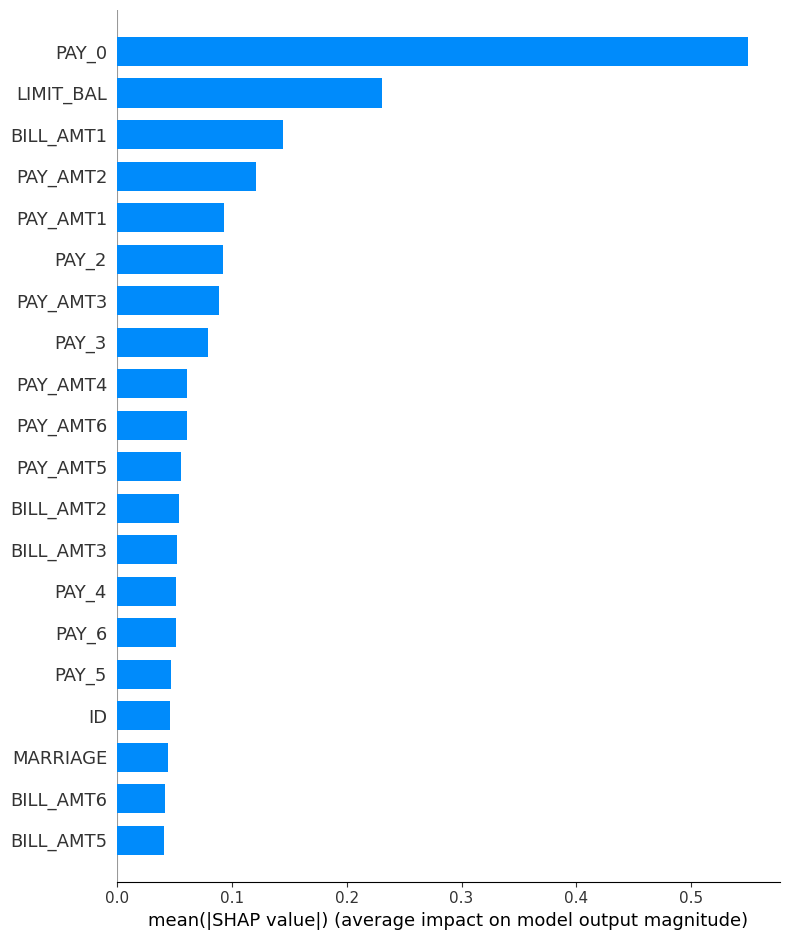

In [16]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [17]:
# Logistic Regression
lr_probs = models["Logistic Regression"].predict_proba(X_test)[:, 1]

# Decision Tree
dt_probs = models["Decision Tree"].predict_proba(X_test)[:, 1]

# XGBoost
xgb_probs = y_prob

In [18]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

ROC Curve Comparison of Models

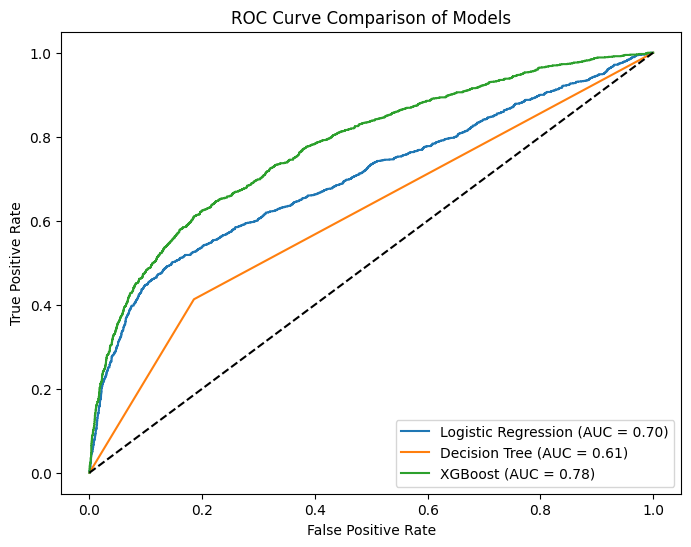

In [19]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = 0.70)')
plt.plot(fpr_dt, tpr_dt, label='Decision Tree (AUC = 0.61)')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = 0.78)')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Models')
plt.legend(loc='lower right')
plt.show()

In [20]:
import shap

shap.initjs()


In [21]:
i = 0  # index of the test sample

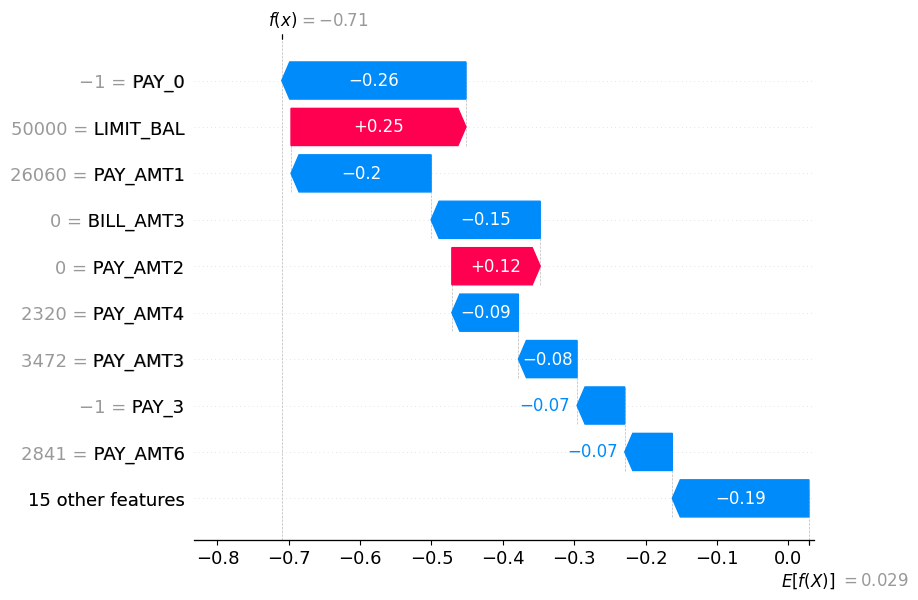

In [22]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test.iloc[i],
        feature_names=X_test.columns
    ),
    max_display=10
)

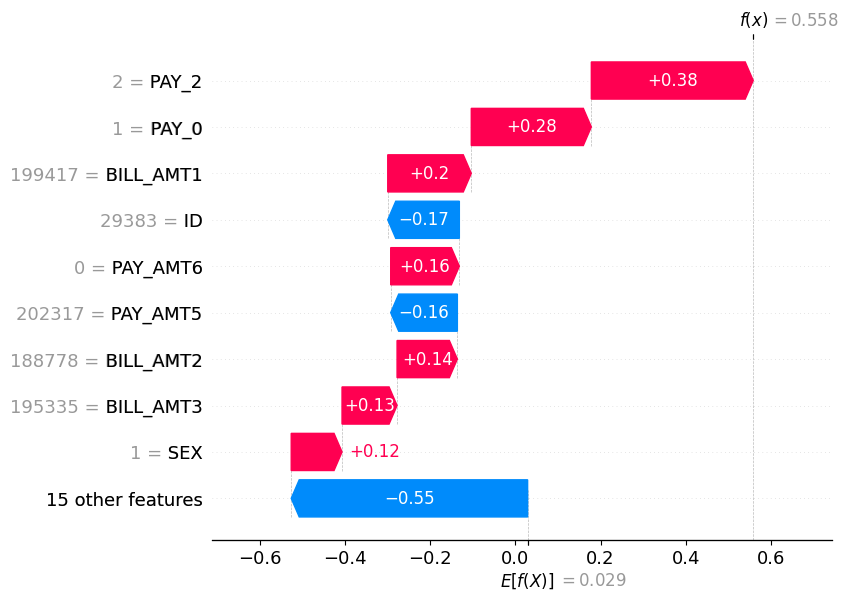

In [23]:
# Find indices where model predicts default
default_indices = X_test.index[xgb_model.predict(X_test) == 1]

# Pick one default case
i = X_test.index.get_loc(default_indices[0])

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test.iloc[i],
        feature_names=X_test.columns
    ),
    max_display=10
)

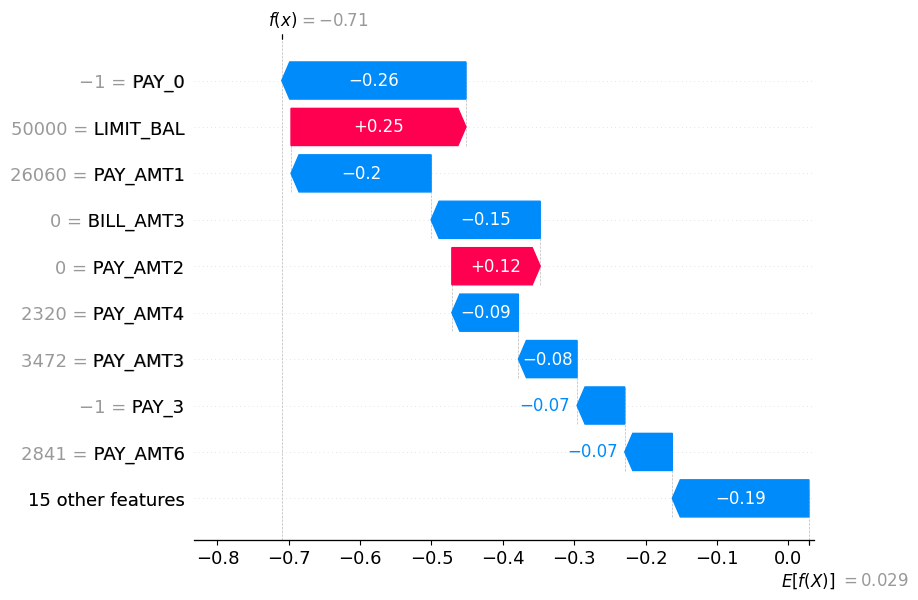

In [24]:
# Find indices where model predicts non-default
non_default_indices = X_test.index[xgb_model.predict(X_test) == 0]

# Pick one non-default case
i = X_test.index.get_loc(non_default_indices[0])

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test.iloc[i],
        feature_names=X_test.columns
    ),
    max_display=10
)

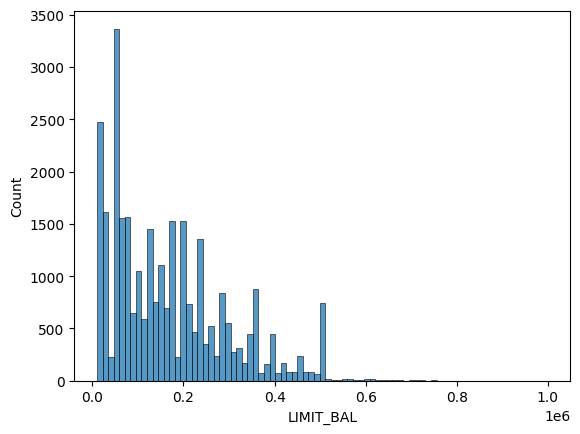

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['LIMIT_BAL'])
plt.show()

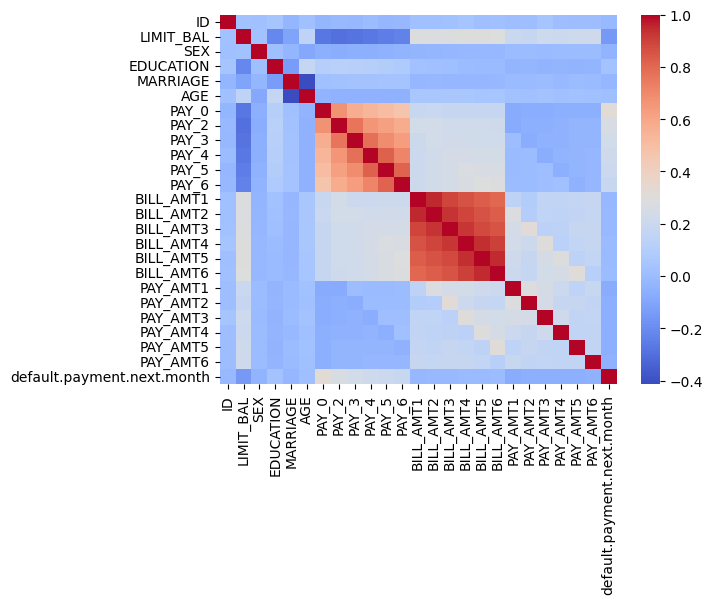

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

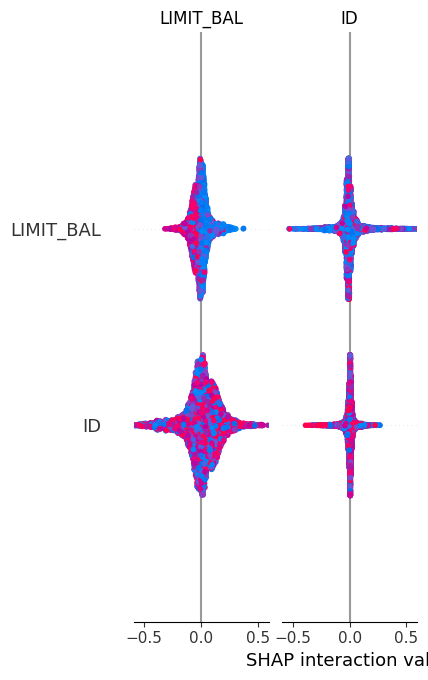

In [27]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [29]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

KS Statistic: 0.22764164448367066


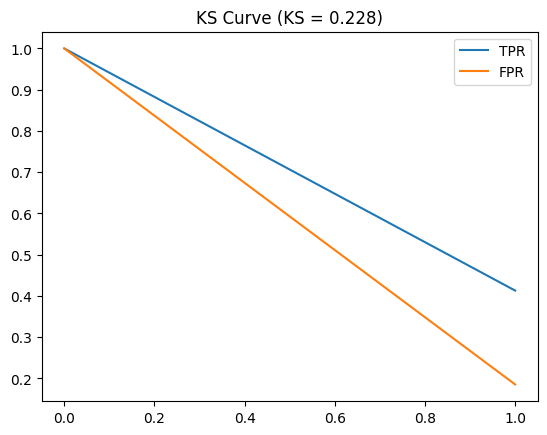

In [30]:
from sklearn.metrics import roc_curve
import numpy as np
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

ks_stat = max(tpr - fpr)
print("KS Statistic:", ks_stat)

plt.plot(thresholds, tpr, label='TPR')
plt.plot(thresholds, fpr, label='FPR')
plt.title(f'KS Curve (KS = {ks_stat:.3f})')
plt.legend()
plt.show()

In [31]:
print(model)
print(X_test.shape)

DecisionTreeClassifier(random_state=42)
(6000, 24)


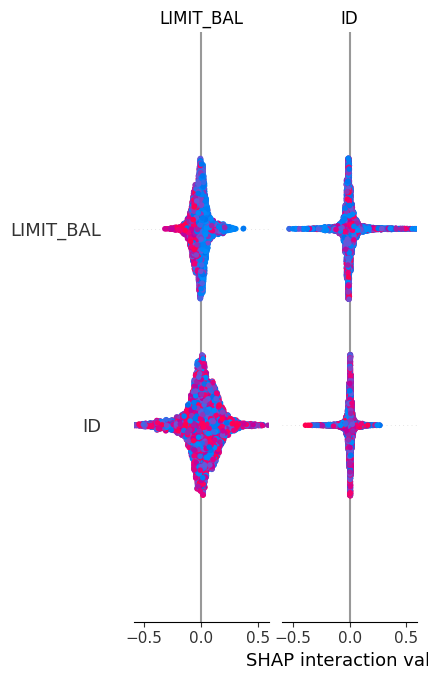

In [32]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

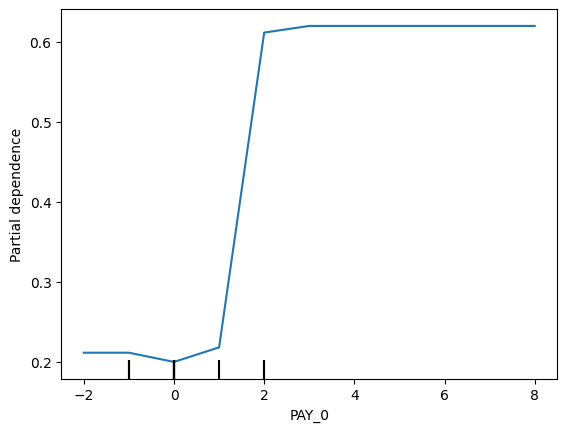

In [33]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

PartialDependenceDisplay.from_estimator(model, X_test, ["PAY_0"])
plt.show()

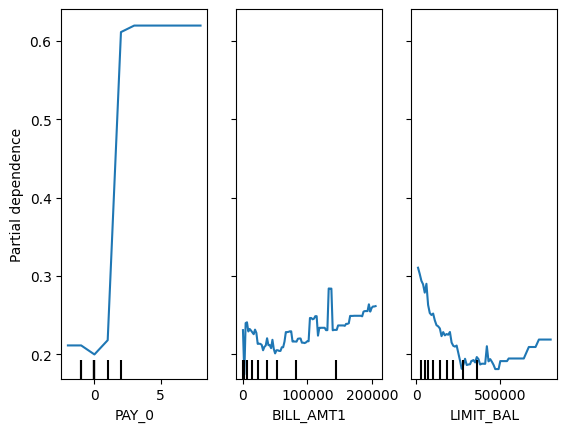

In [34]:
features = ["PAY_0", "BILL_AMT1", "LIMIT_BAL"]

PartialDependenceDisplay.from_estimator(model, X_test, features)
plt.show()

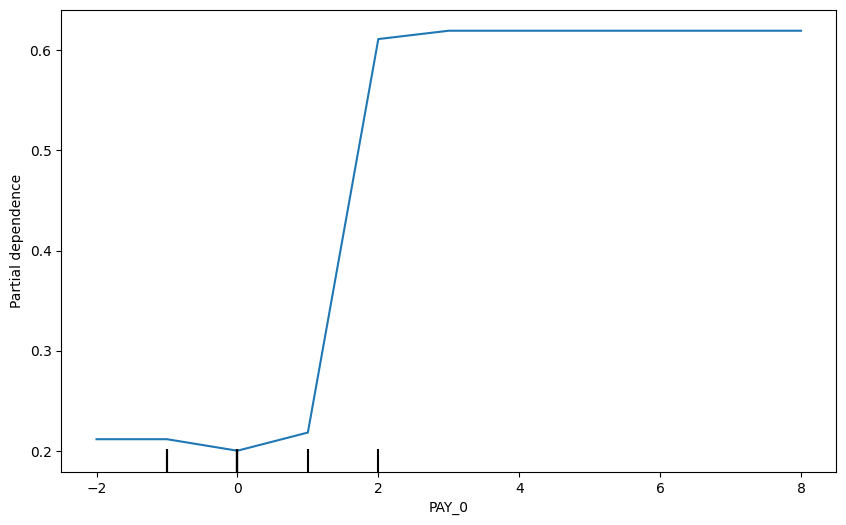

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    ["PAY_0"],
    ax=ax
)

plt.show()

In [37]:
import pandas as pd

In [38]:
file_path = "/content/drive/MyDrive/UCI_Credit_Card.csv"
df = pd.read_csv(file_path)

Default Rate by Key Features

<Axes: xlabel='PAY_0'>

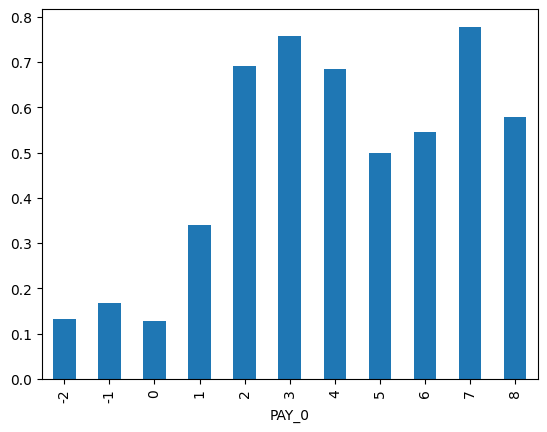

In [39]:
df.groupby("PAY_0")["default.payment.next.month"].mean().plot(kind="bar")

Default vs Non-Default Distribution

<Axes: xlabel='default.payment.next.month', ylabel='count'>

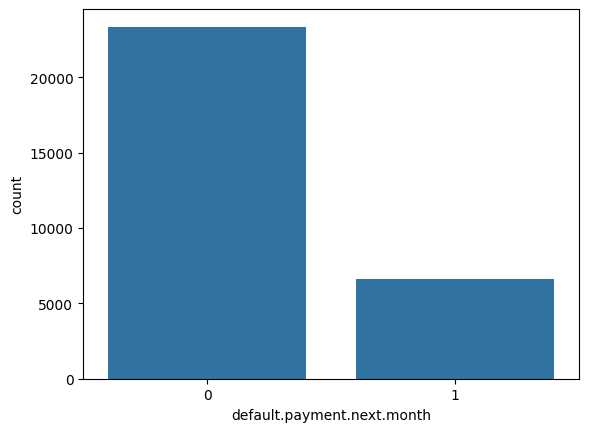

In [40]:
import seaborn as sns

sns.countplot(x="default.payment.next.month", data=df)

Boxplots

<Axes: xlabel='default.payment.next.month', ylabel='LIMIT_BAL'>

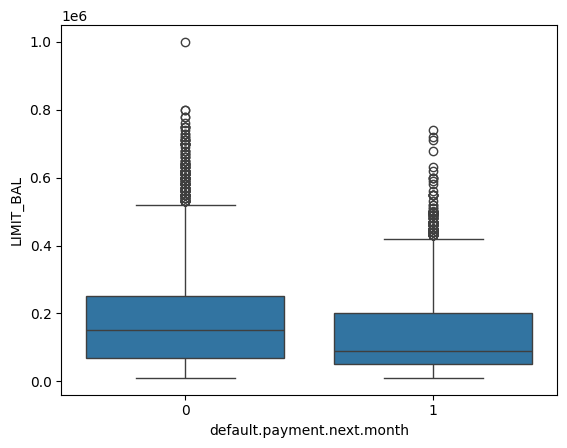

In [41]:
sns.boxplot(x="default.payment.next.month", y="LIMIT_BAL", data=df)

In [45]:
print(type(model))

<class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [46]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss'
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Feature Importance

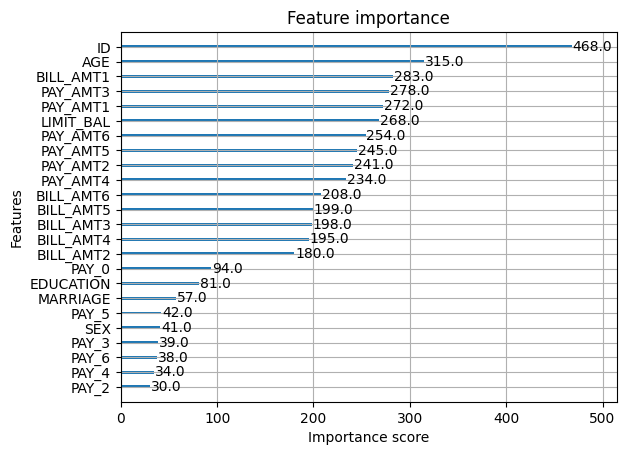

In [47]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

In [48]:
from sklearn.metrics import roc_curve

In [49]:
threshold = 0.5
y_pred_custom = (y_pred_prob > threshold).astype(int)

In [50]:
df_test = X_test.copy()
df_test["prob"] = y_pred_prob

df_test.sort_values("prob", ascending=False).head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,prob
13969,13970,210000.0,2,1,1,38,-1,-1,-1,-2,...,3353.0,10775.0,2938.0,13174.0,16114.0,3353.0,10775.0,3000.0,16520.0,1.0
15703,15704,10000.0,1,2,2,29,0,0,0,0,...,9526.0,9711.0,9764.0,1125.0,1146.0,1307.0,492.0,357.0,901.0,1.0
26966,26967,60000.0,1,2,1,44,0,0,0,0,...,50054.0,27535.0,22962.0,3000.0,2488.0,2000.0,1000.0,2000.0,3000.0,1.0
3560,3561,80000.0,1,3,1,57,2,2,2,2,...,9629.0,10571.0,10749.0,2600.0,350.0,0.0,1100.0,500.0,1300.0,1.0
3054,3055,350000.0,1,1,1,60,1,-1,-1,-1,...,0.0,0.0,1206.0,1150.0,4576.0,0.0,0.0,1206.0,0.0,1.0
1706,1707,230000.0,1,1,2,35,2,2,2,2,...,121464.0,123740.0,120937.0,5800.0,4500.0,3800.0,5000.0,0.0,4500.0,1.0
26706,26707,130000.0,1,2,2,26,2,2,2,0,...,133182.0,103161.0,103031.0,7000.0,0.0,5133.0,5000.0,5000.0,5000.0,1.0
12958,12959,50000.0,1,3,2,23,2,0,0,0,...,10872.0,9392.0,9456.0,1507.0,1500.0,300.0,500.0,500.0,118.0,1.0
17314,17315,40000.0,2,3,1,30,1,2,0,0,...,39078.0,38339.0,38665.0,9.0,2143.0,1606.0,1500.0,1410.0,1507.0,1.0
10942,10943,60000.0,2,3,1,42,-1,-1,2,0,...,390.0,390.0,14290.0,20680.0,0.0,0.0,390.0,14290.0,2892.0,1.0


Distribution Split (Advanced Histogram)

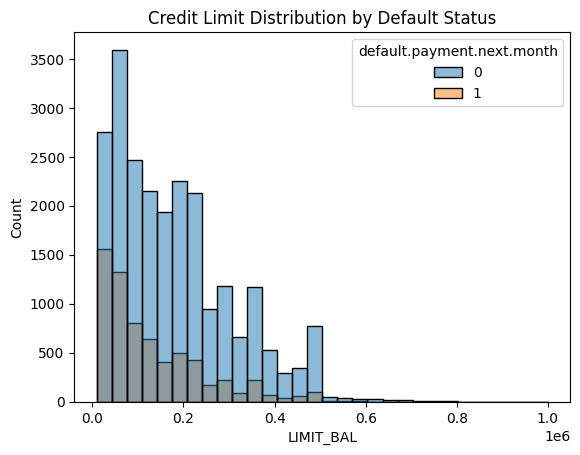

In [55]:
sns.histplot(data=df, x="LIMIT_BAL", hue="default.payment.next.month", bins=30)
plt.title("Credit Limit Distribution by Default Status")
plt.show()

Feature vs Target (Strip Plot – Advanced)

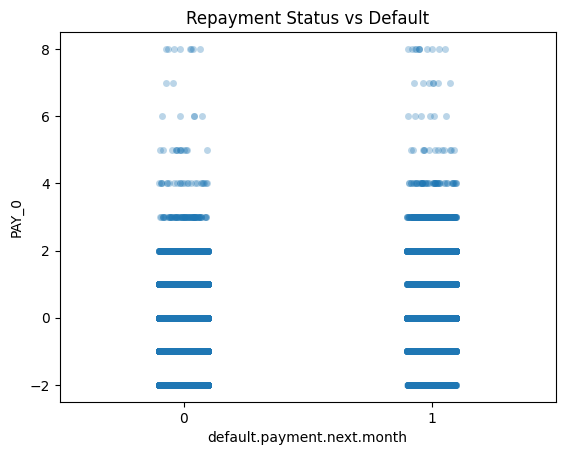

In [56]:
sns.stripplot(x="default.payment.next.month", y="PAY_0", data=df, alpha=0.3)
plt.title("Repayment Status vs Default")
plt.show()

In [57]:
df_test = X_test.copy()
df_test["Default_Prob"] = y_pred_prob

top_risk = df_test.sort_values("Default_Prob", ascending=False).head(10)

print(top_risk)

          ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
13969  13970   210000.0    2          1         1   38     -1     -1     -1   
15703  15704    10000.0    1          2         2   29      0      0      0   
26966  26967    60000.0    1          2         1   44      0      0      0   
3560    3561    80000.0    1          3         1   57      2      2      2   
3054    3055   350000.0    1          1         1   60      1     -1     -1   
1706    1707   230000.0    1          1         2   35      2      2      2   
26706  26707   130000.0    1          2         2   26      2      2      2   
12958  12959    50000.0    1          3         2   23      2      0      0   
17314  17315    40000.0    2          3         1   30      1      2      0   
10942  10943    60000.0    2          3         1   42     -1     -1      2   

       PAY_4  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
13969     -2  ...     3353.0    10775.0     2938.0   131

Precision–Recall Curve

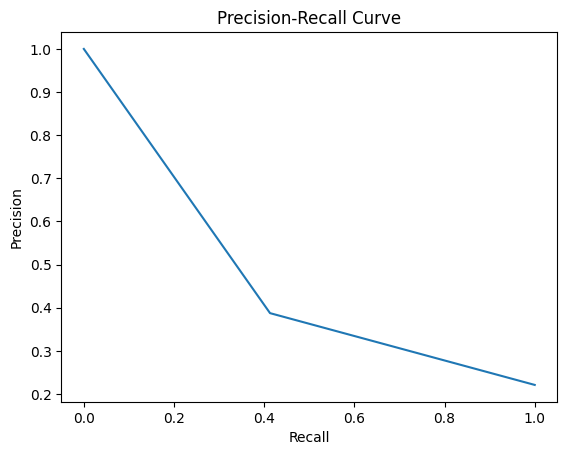

In [59]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()